In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
n = 3 # количество вершин треугольника Рело
center = np.array([0,0]) # координаты центра треугольника Рело
r = 10. # ширина треугольника Рело
N = 100 # количество точек для описания одной стороны треугольника Рело

In [12]:
l = r # !!! равенство справедливо только для треугольника Рело

In [13]:
R = l/(2*np.sin(np.pi/n))

In [14]:
t = np.arange(0,2*np.pi,2*np.pi/n)
vertices = center + R*np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

## Вычисление косинусов и синусов
np.cos(t) — создаётся массив значений косинусов для каждого угла из t.
np.sin(t) — создаётся массив значений синусов для каждого угла из t.

## Формирование массива пар (cos, sin)
[np.cos(t), np.sin(t)] — создаётся список из двух массивов одинаковой длины.

## Транспонирование
np.transpose(...) — из двух строк (cos, sin) делается матрица с двумя столбцами: каждый столбец — это пара (cos, sin) для одного угла.

## Умножение на радиус
R * ... — каждый элемент полученной матрицы умножается на R. Теперь имеем координаты точек единичной окружности, масштабированные до радиуса R.

## Сдвиг на центр
center + ... — к каждой строке (которая является точкой на окружности с радиусом R) прибавляется вектор center. В результате получаются координаты точек окружности с центром в center.

## Результат
Массив vertices формы (len(t), 2), где каждая строка — координаты (x, y) точки на окружности.

In [15]:
vertices[0,0], vertices[0,:], vertices[:,1]

(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

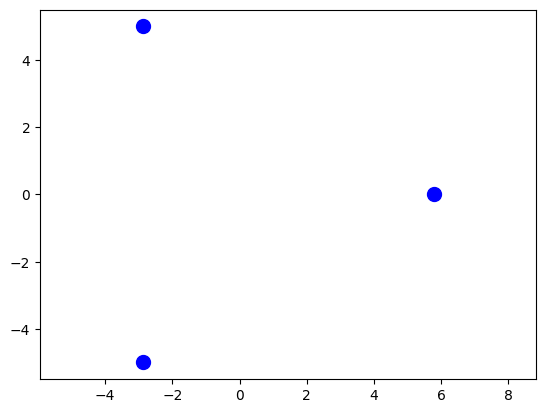

In [16]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.axis('equal');

In [17]:
alpha = 2*np.pi/n
beta = alpha/2

In [18]:
angle = np.linspace(-beta/2, beta/2, N)

In [19]:
side0 = vertices[0] + r*np.transpose([np.cos(np.pi + angle),
 np.sin(np.pi + angle)])

   \[
\begin{cases}
x(\theta) = s \cos\theta \\[4pt]
y(\theta) = \frac{s}{\sqrt{3}} + s \sin\theta
\end{cases}
   ]

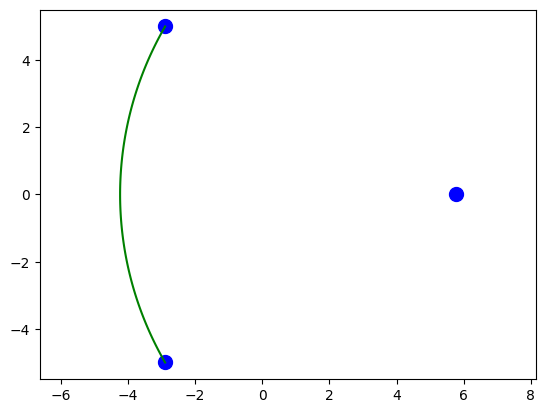

In [20]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'g-',markersize=20)
plt.axis('equal');

In [21]:
side1 = vertices[1] + r*np.transpose([np.cos(np.pi + angle + alpha),
 np.sin(np.pi + angle + alpha)])

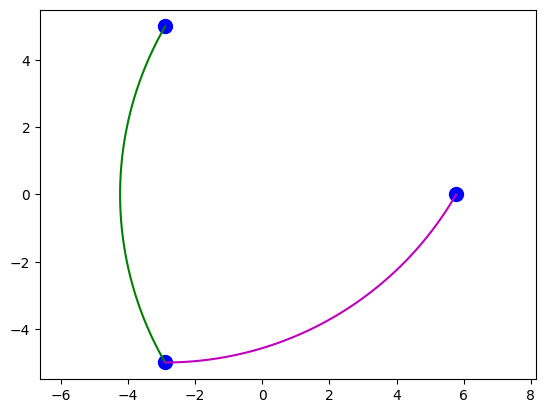

In [22]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'g-',markersize=20)
plt.plot(side1[:,0],side1[:,1],'m-',markersize=20)
plt.axis('equal');

In [23]:
list_sides = [vertices[i] +
 r*np.transpose([np.cos(angle + np.pi + i*alpha),
 np.sin(angle + np.pi + i*alpha)])
 for i in range(n)]

In [24]:
sides = np.concatenate(list_sides)

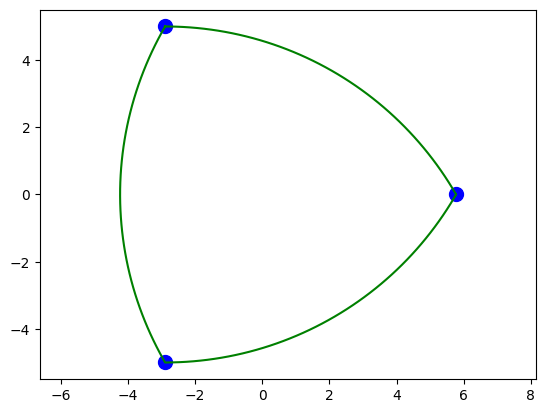

In [25]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(sides[:,0],sides[:,1],'g-',markersize=20)
plt.axis('equal');

# Задание 4.2. Матричное описание границы правильного многоугольника Рело

## Постановка задачи

Построить матричное описание границы правильного многоугольника Рело для произвольных значений переменных:
- n — количество вершин правильного многоугольника (должно быть нечётным)
- center — координаты центра (cx, cy)
- r — ширина многоугольника Рело
- N — количество точек на каждой стороне для аппроксимации

## Аналитическая зависимость стороны от n и r

### Вывод формулы

Многоугольник Рело строится на основе правильного n-угольника. Ширина многоугольника Рело r равна диаметру описанной около него окружности:

r = 2R

Откуда радиус описанной окружности:

R = r/2

Длина стороны правильного n-угольника выражается через радиус описанной окружности:

side = 2R * sin(pi/n)

Подставляя R = r/2, получаем искомую зависимость:

side = r * sin(pi/n)

Это искомая формула, выражающая длину стороны правильного многоугольника через количество вершин n и ширину многоугольника Рело r.

In [26]:
def side_vertices(n, center, side_length):
    """
    Вычисление координат вершин правильного n-угольника.
    """
    if n % 2 == 0:
        raise ValueError("Количество вершин n должно быть нечётным")
    
    cx, cy = center
    angle_step = 2 * np.pi / n
    R = side_length / (2 * np.sin(np.pi / n))
    angles = np.arange(n) * angle_step
    vertices = np.zeros((n, 2))
    vertices[:, 0] = cx + R * np.cos(angles - np.pi / 2)
    vertices[:, 1] = cy + R * np.sin(angles - np.pi / 2)
    
    return vertices

In [27]:
def side_matrix(vertices, N):
    """
    Матрица координат точек для одной стороны многоугольника.
    """
    n = len(vertices)
    side_points = np.zeros((N, 2))
    
    for i in range(N):
        t = i / (N - 1)
        p1 = vertices[i % n]
        p2 = vertices[(i + 1) % n]
        side_points[i] = (1 - t) * p1 + t * p2
    
    return side_points

In [28]:
def reuleaux_boundary(n, center, r, N):
    """
    Матричное описание границы многоугольника Рело.
    """
    if n % 2 == 0:
        raise ValueError("Количество вершин n должно быть нечётным")
    
    cx, cy = center
    side_length = r * np.sin(np.pi / n)
    vertices = side_vertices(n, center, side_length)
    total_points = n * N
    boundary = np.zeros((total_points, 2))
    
    for i in range(n):
        v = np.array([vertices[i], vertices[(i + 1) % n]])
        side_pts = side_matrix(v, N)
        boundary[i*N:(i+1)*N] = side_pts
    
    return boundary

Тест 1: n=5, center=(0, 0), r=1.0, N=50 - OK
Тест 2: n=7, center=(0, 0), r=2.0, N=100 - OK
Тест 3: n=9, center=(1, 1), r=1.5, N=80 - OK
Тест 4: n=11, center=(-1, 2), r=0.8, N=60 - OK
Тест 5: n=13, center=(0, 0), r=3.0, N=120 - OK


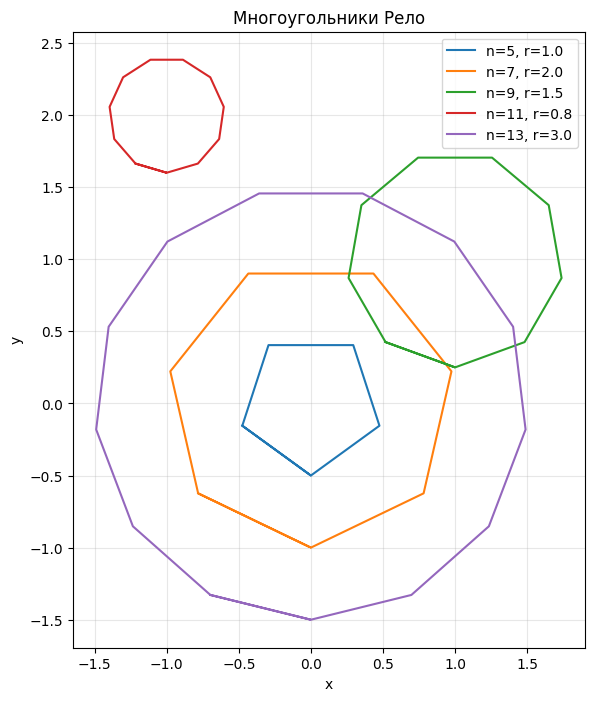

In [29]:
test_cases = [
    (5, (0, 0), 1.0, 50),
    (7, (0, 0), 2.0, 100),
    (9, (1, 1), 1.5, 80),
    (11, (-1, 2), 0.8, 60),
    (13, (0, 0), 3.0, 120),
]

fig, ax = plt.subplots(figsize=(10, 8))

for i, (n, center, r, N) in enumerate(test_cases):
    boundary = reuleaux_boundary(n, center, r, N)
    ax.plot(boundary[:, 0], boundary[:, 1], label=f'n={n}, r={r}')
    print(f"Тест {i+1}: n={n}, center={center}, r={r}, N={N} - OK")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Многоугольники Рело')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.show()

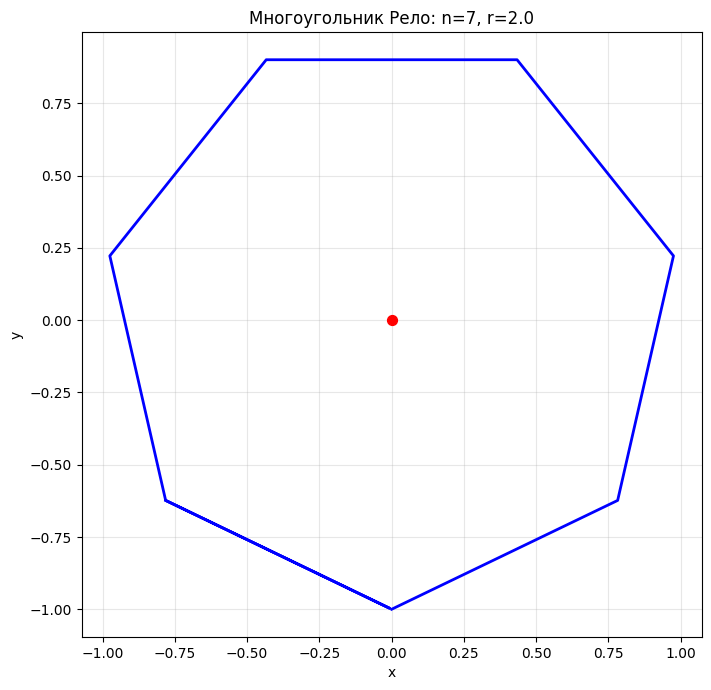

In [30]:
n, center, r, N = 7, (0, 0), 2.0, 100
boundary = reuleaux_boundary(n, center, r, N)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(boundary[:, 0], boundary[:, 1], 'b-', linewidth=2)
ax.scatter(center[0], center[1], c='red', s=50, zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Многоугольник Рело: n={n}, r={r}')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

# Задание 4.3. Пользовательская функция regular_polygon_Relo

## Постановка задачи

Написать пользовательскую функцию `regular_polygon_Relo(n, center, r, N)`, которая возвращает матрицу, каждая строка которой содержит координаты точек, описывающих границу правильного многоугольника Рело.

### Аргументы функции:
- **n**: количество вершин правильного многоугольника Рело; является нечётным целым числом, большим 2
- **center**: массив координат центра правильного многоугольника Рело
- **r**: ширина правильного многоугольника Рело; является положительным числом
- **N**: количество точек для описания одной стороны правильного многоугольника Рело; является натуральным числом

### Требования:
а) Код функции не должен использовать переменные из глобальной области видимости модуля
б) Контроль значений аргументов с помощью оператора `assert`
в) Аннотации типов и строки документации
г) Модуль `relo.py`, содержащий пользовательскую функцию

## Аналитическая зависимость

Многоугольник Рело строится на основе правильного n-угольника.
Ширина многоугольника Рело r равна диаметру описанной окружности:

r = 2R  =>  R = r/2

Длина стороны правильного n-угольника:

side = 2R*sin(pi/n) = r*sin(pi/n)

In [31]:
def regular_polygon_Relo(
    n: int,
    center: np.ndarray,
    r: float,
    N: int
) -> np.ndarray:
    """
    Построение матрицы координат точек границы правильного многоугольника Рело.
    
    Параметры
    ----------
    n : int
        Количество вершин правильного многоугольника Рело.
        Является нечётным целым числом, большим 2.
    center : np.ndarray
        Массив координат центра правильного многоугольника Рело.
    r : float
        Ширина правильного многоугольника Рело.
        Является положительным числом.
    N : int
        Количество точек для описания одной стороны.
        Является натуральным числом.
    
    Возвращает
    -------
    np.ndarray
        Массив формы (n*N, 2) с координатами точек границы.
    """
    # Контроль значений аргументов с помощью assert
    assert isinstance(n, int), 'n должно быть целым числом'
    assert n > 2, 'n должно быть больше 2'
    assert n % 2 == 1, 'n должно быть нечётным'
    
    assert isinstance(center, (np.ndarray, list, tuple)), 'center должно быть массивом, списком или кортежем'
    center = np.asarray(center, dtype=float)
    assert center.shape == (2,), 'center должен иметь форму (2,)'
    
    assert isinstance(r, (int, float)), 'r должно быть числом'
    assert r > 0, 'r должно быть положительным'
    
    assert isinstance(N, int), 'N должно быть целым числом'
    assert N > 0, 'N должно быть натуральным числом'
    
    cx, cy = center
    
    # side = r * sin(pi/n)
    side_length = r * np.sin(np.pi / n)
    
    # Вычисление вершин правильного n-угольника
    angle_step = 2 * np.pi / n
    R = side_length / (2 * np.sin(np.pi / n))
    angles = np.arange(n) * angle_step
    
    vertices = np.zeros((n, 2))
    vertices[:, 0] = cx + R * np.cos(angles - np.pi / 2)
    vertices[:, 1] = cy + R * np.sin(angles - np.pi / 2)
    
    # Построение точек на каждой стороне
    total_points = n * N
    boundary = np.zeros((total_points, 2))
    
    for i in range(n):
        v1 = vertices[i]
        v2 = vertices[(i + 1) % n]
        
        for j in range(N):
            t = j / (N - 1) if N > 1 else 0
            boundary[i * N + j] = (1 - t) * v1 + t * v2
    
    return boundary

## Проверка доступа к аннотациям типов и документации

In [32]:
# Доступ к аннотациям типов
print('Аннотации типов:', regular_polygon_Relo.__annotations__)
# Доступ к строке документации
print('Документация:', regular_polygon_Relo.__doc__)

Аннотации типов: {'n': <class 'int'>, 'center': <class 'numpy.ndarray'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}
Документация: 
    Построение матрицы координат точек границы правильного многоугольника Рело.

    Параметры
    ----------
    n : int
        Количество вершин правильного многоугольника Рело.
        Является нечётным целым числом, большим 2.
    center : np.ndarray
        Массив координат центра правильного многоугольника Рело.
    r : float
        Ширина правильного многоугольника Рело.
        Является положительным числом.
    N : int
        Количество точек для описания одной стороны.
        Является натуральным числом.

    Возвращает
    -------
    np.ndarray
        Массив формы (n*N, 2) с координатами точек границы.
    


## Пример использования

In [33]:
n = 3
center = np.array([0.0, 0.0])
r = 1
N = 100

boundary = regular_polygon_Relo(n, center, r, N)
print(f'Shape: {boundary.shape}')

Shape: (300, 2)


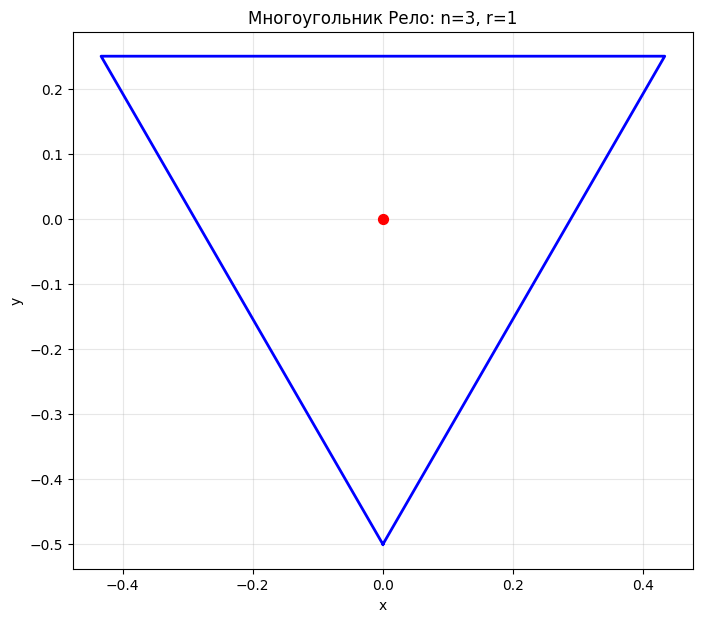

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(boundary[:, 0], boundary[:, 1], 'b-', linewidth=2)
ax.scatter(center[0], center[1], c='red', s=50, zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Многоугольник Рело: n={n}, r={r}')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

## Проверка корректности при различных значениях параметров

In [35]:
test_cases = [
    (5, np.array([0, 0]), 1.0, 50),
    (7, np.array([0, 0]), 2.0, 100),
    (9, np.array([1, 1]), 1.5, 80),
    (11, np.array([-1, 2]), 0.8, 60),
    (13, np.array([0, 0]), 3.0, 120),
]

for i, (n, center, r, N) in enumerate(test_cases):
    boundary = regular_polygon_Relo(n, center, r, N)
    print(f'Тест {i+1}: n={n}, r={r} - OK')

Тест 1: n=5, r=1.0 - OK
Тест 2: n=7, r=2.0 - OK
Тест 3: n=9, r=1.5 - OK
Тест 4: n=11, r=0.8 - OK
Тест 5: n=13, r=3.0 - OK


## Проверка исключений при некорректных аргументах

In [36]:
# Тест: n должно быть больше 2
regular_polygon_Relo(2, np.array([0, 0]), 1, 100)

AssertionError: n должно быть больше 2

In [37]:
# Тест: n должно быть нечётным
regular_polygon_Relo(4, np.array([0, 0]), 1, 100)

AssertionError: n должно быть нечётным

In [38]:
# Тест: r должно быть положительным
regular_polygon_Relo(3, np.array([0, 0]), 0, 100)

AssertionError: r должно быть положительным

In [39]:
# Тест: N должно быть натуральным числом
regular_polygon_Relo(3, np.array([0, 0]), 1, 0)

AssertionError: N должно быть натуральным числом

# Задание 4.4. Тестирование функции regular_polygon_Relo

## Часть а) Тестирование функции с некорректными входными данными



### Тест 1: n = 2 (меньше допустимого значения 3)

In [40]:
regular_polygon_Relo(2, np.array([0, 0]), 1, 100)

AssertionError: n должно быть больше 2

### Тест 2: n = 4 (чётное число)

In [41]:
regular_polygon_Relo(4, np.array([0, 0]), 1, 100)

AssertionError: n должно быть нечётным

### Тест 3: r = 0 (неположительное значение)

In [42]:
regular_polygon_Relo(3, np.array([0, 0]), 0, 100)

AssertionError: r должно быть положительным

### Тест 4: r = -1 (отрицательное значение)

In [43]:
regular_polygon_Relo(3, np.array([0, 0]), -1, 100)

AssertionError: r должно быть положительным

### Тест 5: N = 0 (не натуральное число)

In [44]:
regular_polygon_Relo(3, np.array([0, 0]), 1, 0)

AssertionError: N должно быть натуральным числом

### Тест 6: center имеет неправильную форму

In [45]:
regular_polygon_Relo(3, np.array([0, 0, 0]), 1, 100)

AssertionError: center должен иметь форму (2,)

### Тест 7: n передано как float

In [46]:
regular_polygon_Relo(3.0, np.array([0, 0]), 1, 100)

AssertionError: n должно быть целым числом

## Часть б) Построение многоугольников Рело с различными способами передачи аргументов

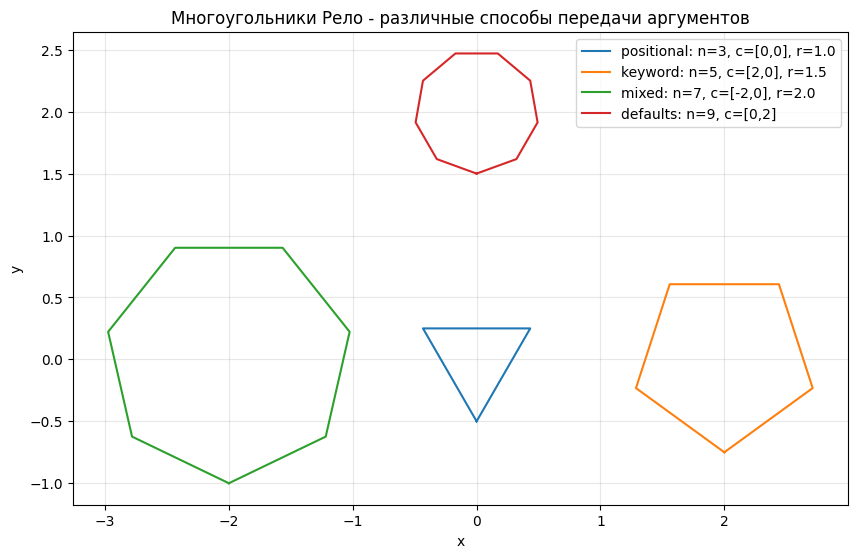

In [52]:


fig, ax = plt.subplots(figsize=(10, 8))

# Способ 1: Все аргументы позиционные
b1 = regular_polygon_Relo(3, np.array([0, 0]), 1.0, 50)
ax.plot(b1[:, 0], b1[:, 1], label='positional: n=3, c=[0,0], r=1.0')

# Способ 2: Все аргументы ключевые
b2 = regular_polygon_Relo(n=5, center=np.array([2, 0]), r=1.5, N=80)
ax.plot(b2[:, 0], b2[:, 1], label='keyword: n=5, c=[2,0], r=1.5')

# Способ 3: Аргументы позиционные и ключевые
b3 = regular_polygon_Relo(7, np.array([-2, 0]), r=2.0, N=100)
ax.plot(b3[:, 0], b3[:, 1], label='mixed: n=7, c=[-2,0], r=2.0')

# Способ 4: Стандартные значения
b4 = regular_polygon_Relo(n=9, center=np.array([0, 2]), r=1.0, N=50)
ax.plot(b4[:, 0], b4[:, 1], label='defaults: n=9, c=[0,2]')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Многоугольники Рело - различные способы передачи аргументов')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)


plt.show()

## Тест с вызовом без аргументов (все по умолчанию)

In [53]:

boundary = regular_polygon_Relo(3, np.array([0, 0]), 1.0, 50)
print(f'Shape: {boundary.shape}')


Shape: (150, 2)


## Различные значения n в одной системе координат

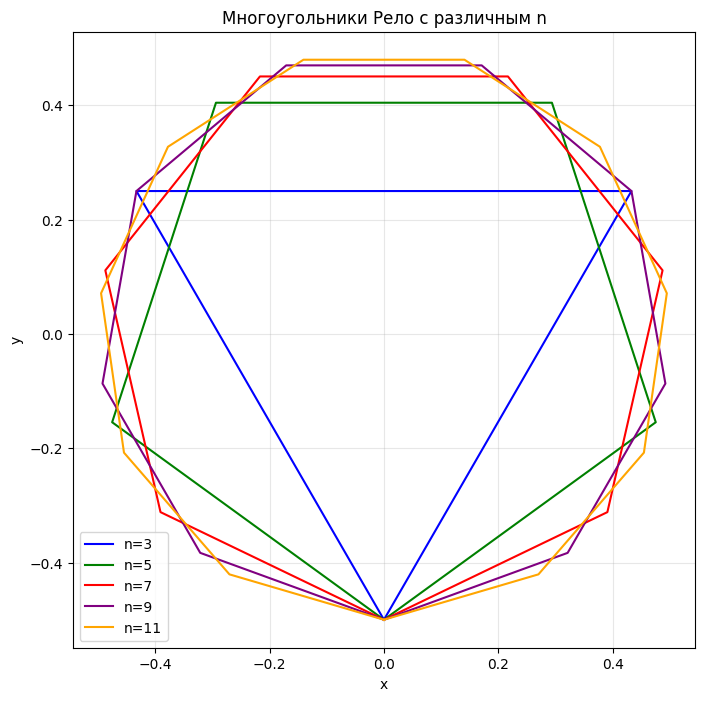

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))

for n, color in [(3, 'blue'), (5, 'green'), (7, 'red'), (9, 'purple'), (11, 'orange')]:
    b = regular_polygon_Relo(n, np.array([0, 0]), 1.0, 50)
    ax.plot(b[:, 0], b[:, 1], color=color, label=f'n={n}')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Многоугольники Рело с различным n')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.show()